# Визуализация данных с помощью Python

## 1. Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Установка seed для воспроизводимости результатов
np.random.seed(19)

## 2. Создание серий данных

In [2]:
# 1.1 Серия X (числа от 0 до 99)
X = pd.Series(np.arange(100))

# 1.2 Серия Y1 (100 случайных чисел с нормальным распределением)
Y1 = pd.Series(np.random.normal(0, 1, 100))

# 1.3 Серия Y2 (вычисляется по формуле y2[i] = x[i] + e[i])
# где e[i] - случайное целое из диапазона [-2; 2]
e = np.random.randint(-2, 3, 100)
Y2 = X + e

print("Первые 10 значений каждой серии:")
print(f"X:  {X.head(10).tolist()}")
print(f"Y1: {Y1.head(10).round(3).tolist()}")
print(f"Y2: {Y2.head(10).tolist()}")

Первые 10 значений каждой серии:
X:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Y1: [0.497, -0.138, 0.648, 1.523, -0.234, -0.234, 1.579, 0.767, -0.469, 0.543]
Y2: [-2, 3, 0, 3, 3, 6, 6, 5, 9, 7]


## 3. Создание датафрейма

In [3]:
# 2. Создаем датафрейм из серий
df = pd.DataFrame({'X': X, 'Y1': Y1, 'Y2': Y2})

# Добавляем столбец с разностью X - Y2 для дальнейшего использования
df['X_minus_Y2'] = df['X'] - df['Y2']

# Выводим основную информацию о датафрейме
print("Информация о датафрейме:")
print(df.info())

print("\nПервые 5 строк датафрейма:")
print(df.head())

print("\nОписательная статистика:")
print(df.describe().round(3))

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           100 non-null    int64  
 1   Y1          100 non-null    float64
 2   Y2          100 non-null    int64  
 3   X_minus_Y2  100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB
None

Первые 5 строк датафрейма:
   X        Y1  Y2  X_minus_Y2
0  0  0.496714  -2           2
1  1 -0.138264   3          -2
2  2  0.647689   0           2
3  3  1.523030   3           0
4  4 -0.234153   3           1

Описательная статистика:
             X       Y1       Y2  X_minus_Y2
count  100.000  100.000  100.000      100.00
mean    49.500   -0.104   49.180        0.32
std     29.011    0.908   29.067        1.34
min      0.000   -2.620   -2.000       -2.00
25%     24.750   -0.601   24.750       -1.00
50%     49.500   -0.127   50.000        0.00
75%     74.250  

## 4. Точечная диаграмма (диаграмма рассеяния) X и Y2

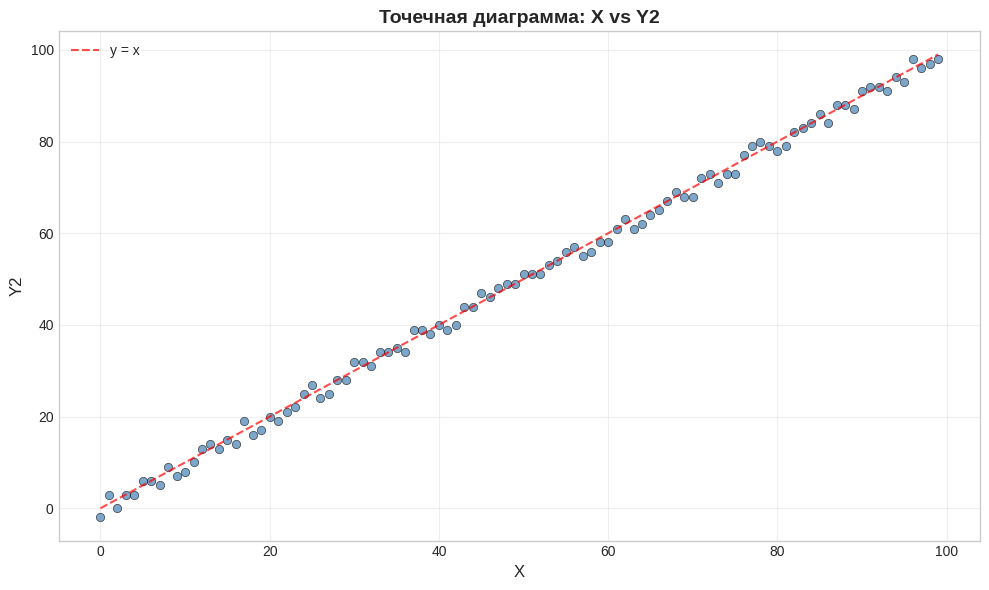

Коэффициент корреляции между X и Y2: 0.9989


In [4]:
# 3. Точечная диаграмма для X и Y2
plt.figure(figsize=(10, 6))

# Строим точечную диаграмму
plt.scatter(df['X'], df['Y2'], alpha=0.7, c='steelblue', edgecolors='black', linewidth=0.5)

# Добавляем линию идеальной зависимости (y = x)
plt.plot(df['X'], df['X'], color='red', linestyle='--', alpha=0.7, label='y = x')

# Настройки графика
plt.title('Точечная диаграмма: X vs Y2', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Дополнительная информация о связи между X и Y2
correlation = df['X'].corr(df['Y2'])
print(f"Коэффициент корреляции между X и Y2: {correlation:.4f}")

## 5. Линейная диаграмма зависимости Y1 от X

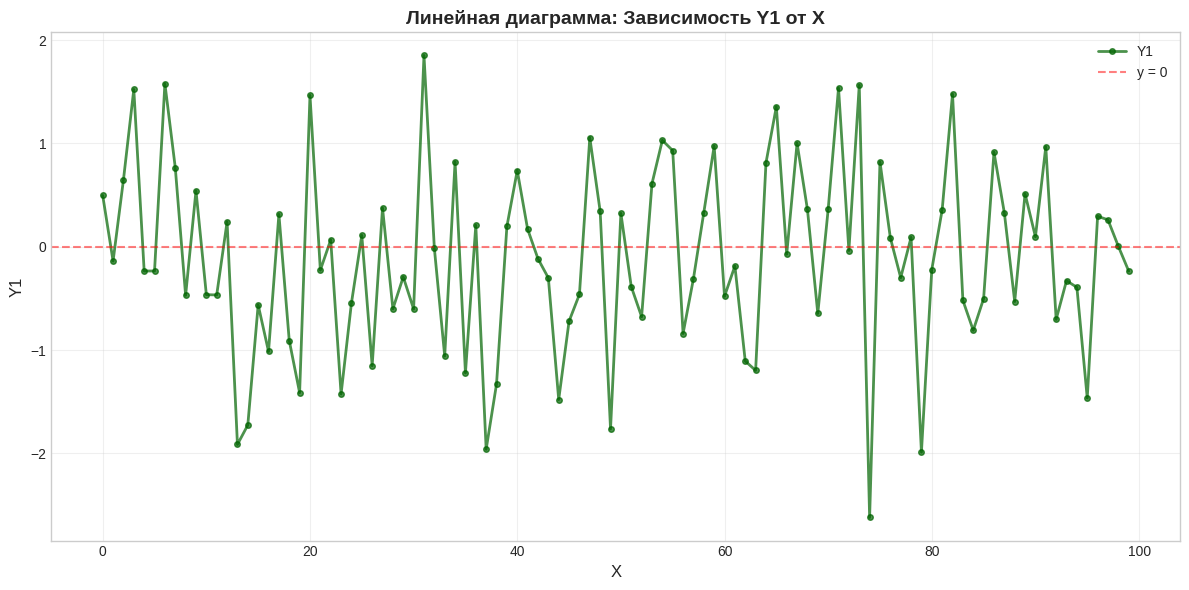

Статистика для Y1:
Среднее значение: -0.1038
Стандартное отклонение: 0.9082
Минимальное значение: -2.6197
Максимальное значение: 1.8523


In [5]:
# 4. Линейная диаграмма Y1 от X
plt.figure(figsize=(12, 6))

# Строим линейный график
plt.plot(df['X'], df['Y1'], color='darkgreen', linewidth=2, marker='o', 
         markersize=4, alpha=0.7, label='Y1')

# Добавляем горизонтальную линию на уровне y=0
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='y = 0')

# Настройки графика
plt.title('Линейная диаграмма: Зависимость Y1 от X', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y1', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Дополнительная статистика по Y1
print("Статистика для Y1:")
print(f"Среднее значение: {df['Y1'].mean():.4f}")
print(f"Стандартное отклонение: {df['Y1'].std():.4f}")
print(f"Минимальное значение: {df['Y1'].min():.4f}")
print(f"Максимальное значение: {df['Y1'].max():.4f}")

## 6. Гистограмма частот для Y1 (10 диапазонов)

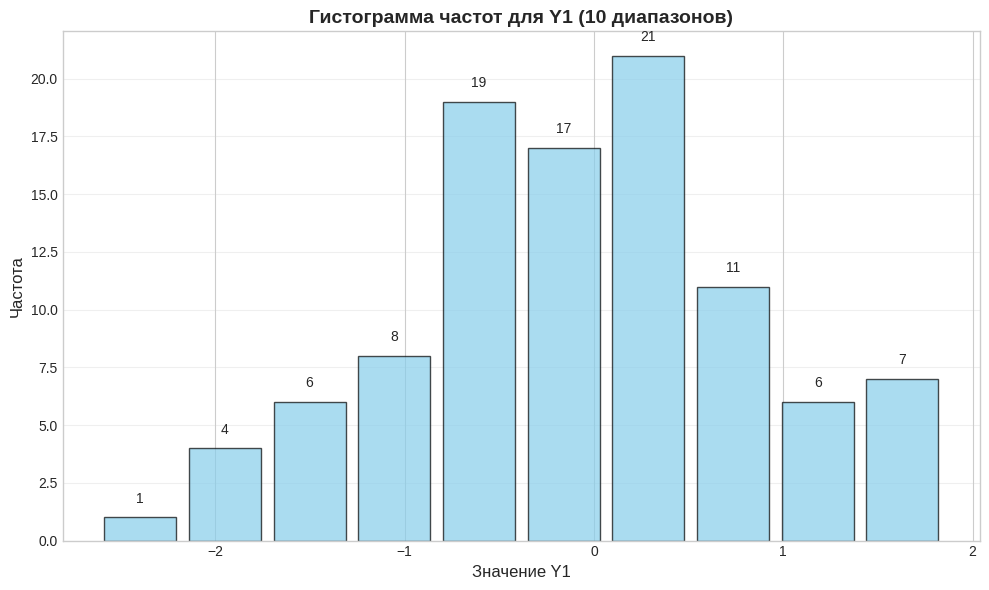

Информация о гистограмме:
Количество интервалов: 10
Границы интервалов: [-2.62 -2.17 -1.73 -1.28 -0.83 -0.38  0.06  0.51  0.96  1.41  1.85]
Количество наблюдений в каждом интервале: [ 1  4  6  8 19 17 21 11  6  7]


In [6]:
# 5. Гистограмма для Y1 с 10 диапазонами (бинами)
plt.figure(figsize=(10, 6))

# Строим гистограмму
n, bins, patches = plt.hist(df['Y1'], bins=10, color='skyblue', 
                            edgecolor='black', alpha=0.7, rwidth=0.85)

# Добавляем значения над столбцами
for i in range(len(n)):
    if n[i] > 0:  # Показываем только ненулевые значения
        plt.text(bins[i] + (bins[i+1] - bins[i])/2, n[i] + 0.5, 
                 str(int(n[i])), ha='center', va='bottom', fontsize=10)

# Настройки графика
plt.title('Гистограмма частот для Y1 (10 диапазонов)', fontsize=14, fontweight='bold')
plt.xlabel('Значение Y1', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Дополнительная информация о распределении
print("Информация о гистограмме:")
print(f"Количество интервалов: {len(bins)-1}")
print(f"Границы интервалов: {bins.round(2)}")
print(f"Количество наблюдений в каждом интервале: {n.astype(int)}")

## 7. Разделение данных на группы и построение boxplot для Y1

Количество наблюдений в каждой группе:
Group
X-Y2 > 0    45
X-Y2 < 0    32
X-Y2 = 0    23
Name: count, dtype: int64


/tmp/ipykernel_16749/2082584710.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(x='Group', y='Y1', data=df, palette='Set2')


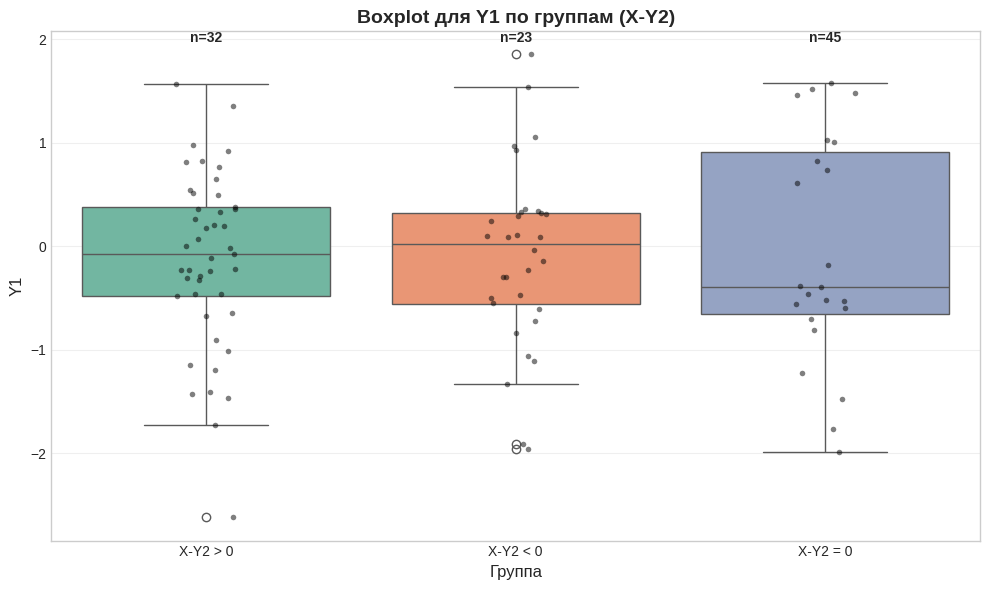


Статистика по Y1 для каждой группы:

Группа 'X-Y2 < 0':
  Количество: 32
  Среднее: -0.0970
  Медиана: 0.0256
  Стандартное отклонение: 0.8684

Группа 'X-Y2 = 0':
  Количество: 23
  Среднее: -0.0583
  Медиана: -0.3921
  Стандартное отклонение: 1.0952

Группа 'X-Y2 > 0':
  Количество: 45
  Среднее: -0.1319
  Медиана: -0.0720
  Стандартное отклонение: 0.8501


In [7]:
# 6. Разделение данных на 3 группы по значению разности X-Y2
# Создаем новую колонку для группировки
conditions = [
    df['X_minus_Y2'] < 0,
    df['X_minus_Y2'] == 0,
    df['X_minus_Y2'] > 0
]

labels = ['X-Y2 < 0', 'X-Y2 = 0', 'X-Y2 > 0']

df['Group'] = np.select(conditions, labels, default='Other')

# Выводим количество наблюдений в каждой группе
print("Количество наблюдений в каждой группе:")
print(df['Group'].value_counts())

# Создаем boxplot для каждой группы
plt.figure(figsize=(10, 6))

# Используем seaborn для более красивого boxplot
boxplot = sns.boxplot(x='Group', y='Y1', data=df, palette='Set2')

# Добавляем точки для отображения всех наблюдений
sns.stripplot(x='Group', y='Y1', data=df, color='black', 
              alpha=0.5, size=4, jitter=True)

# Настройки графика
plt.title('Boxplot для Y1 по группам (X-Y2)', fontsize=14, fontweight='bold')
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Y1', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем аннотации с количеством наблюдений в каждой группе
group_counts = df['Group'].value_counts()
for i, group in enumerate(labels):
    count = group_counts.get(group, 0)
    plt.text(i, df['Y1'].max() * 1.05, f'n={count}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Дополнительная статистика по группам
print("\nСтатистика по Y1 для каждой группы:")
for group in labels:
    group_data = df[df['Group'] == group]['Y1']
    if len(group_data) > 0:
        print(f"\nГруппа '{group}':")
        print(f"  Количество: {len(group_data)}")
        print(f"  Среднее: {group_data.mean():.4f}")
        print(f"  Медиана: {group_data.median():.4f}")
        print(f"  Стандартное отклонение: {group_data.std():.4f}")

## 8. Дополнительный анализ: сводная таблица

In [8]:
# Создаем сводную таблицу для дополнительного анализа
pivot_table = df.pivot_table(
    values=['Y1', 'Y2', 'X_minus_Y2'],
    index='Group',
    aggfunc=['count', 'mean', 'std', 'min', 'max']
).round(3)

print("Сводная таблица по группам:")
print(pivot_table)

Сводная таблица по группам:
              count               mean                       std         \
         X_minus_Y2  Y1  Y2 X_minus_Y2     Y1      Y2 X_minus_Y2     Y1   
Group                                                                     
X-Y2 < 0         32  32  32     -1.281 -0.097  50.375      0.457  0.868   
X-Y2 = 0         23  23  23      0.000 -0.058  52.522      0.000  1.095   
X-Y2 > 0         45  45  45      1.622 -0.132  46.622      0.490  0.850   

                        min                  max             
              Y2 X_minus_Y2     Y1 Y2 X_minus_Y2     Y1  Y2  
Group                                                        
X-Y2 < 0  28.047         -2 -1.960  3         -1  1.852  98  
X-Y2 = 0  27.742          0 -1.988  3          0  1.579  94  
X-Y2 > 0  30.797          1 -2.620 -2          2  1.565  98  
